# Set Up

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load Data Set

In [20]:
df = pd.read_csv("final_streaming_dataset.csv")

print(df.shape)
df.head()

(96200, 52)


,popularity_norm,engagement_score,release_date,popularity,id,adult,spoken_languages,hidden_gem,vote_average,network,...,topic_politics,topic_climate,topic_war,topic_family,topic_crime,topic_romance,topic_technology,topic_diversity_score,cluster,cluster_label
0,0.916136,7.789985,2018-10-16,385.1942,79744,0.0,English,0,8.529,NaN,...,0,0,0,0,0,0,0,0,2,High Visibility
1,1.000000,2.340317,2026-02-12,420.4551,1265609,0.0,English,0,7.238,NaN,...,0,0,1,0,0,0,1,2,2,High Visibility
2,0.796415,27.603475,2005-03-27,334.8569,1416,0.0,English,0,8.209,NaN,...,0,0,0,0,0,0,0,0,2,High Visibility
3,0.830130,21.134389,2005-09-13,349.0323,1622,0.0,English,0,8.300,NaN,...,0,0,1,1,0,0,1,3,2,High Visibility
4,0.445930,67.621359,2011-04-17,187.4934,1399,0.0,English,0,8.458,NaN,...,0,0,1,0,0,0,0,1,2,High Visibility


# Define Features

In [21]:
topic_cols = [col for col in df.columns if col.startswith("topic_")]

features = [
    "popularity",
    "vote_count",
    "vote_average",
    "release_year",
    "runtime_final",
    "visibility_score",
    "engagement_score",
    "audience_reception_score",
    "topic_diversity_score"
] + topic_cols

target = "business_value_score"

# Prepare Data

In [22]:
X = df[features].copy()
y = df[target]

# Fill missing values
X = X.fillna(0)
y = y.fillna(y.median())

# Train / Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (76960, 18)
Test shape: (19240, 18)


# Linear Regression

In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Evaluate Linear Reegression

RSME = AVG prediction error
R^2 = how much variance i explain (closer to 1 better)

In [25]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R²:", r2_lr)

Linear Regression RMSE: 1.0221955294132195
Linear Regression R²: 0.8143441314709043


# Random Forest

In [26]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Evaluate Random Forest 

In [27]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 0.31685364305543307
Random Forest R²: 0.9821615080425875


# Feature Importance 

In [28]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(10))

vote_average                0.372811
audience_reception_score    0.195938
release_year                0.165524
vote_count                  0.124212
popularity                  0.105681
visibility_score            0.021392
engagement_score            0.013427
runtime_final               0.000331
topic_diversity_score       0.000170
topic_technology            0.000163
dtype: float64


plot feature importance 

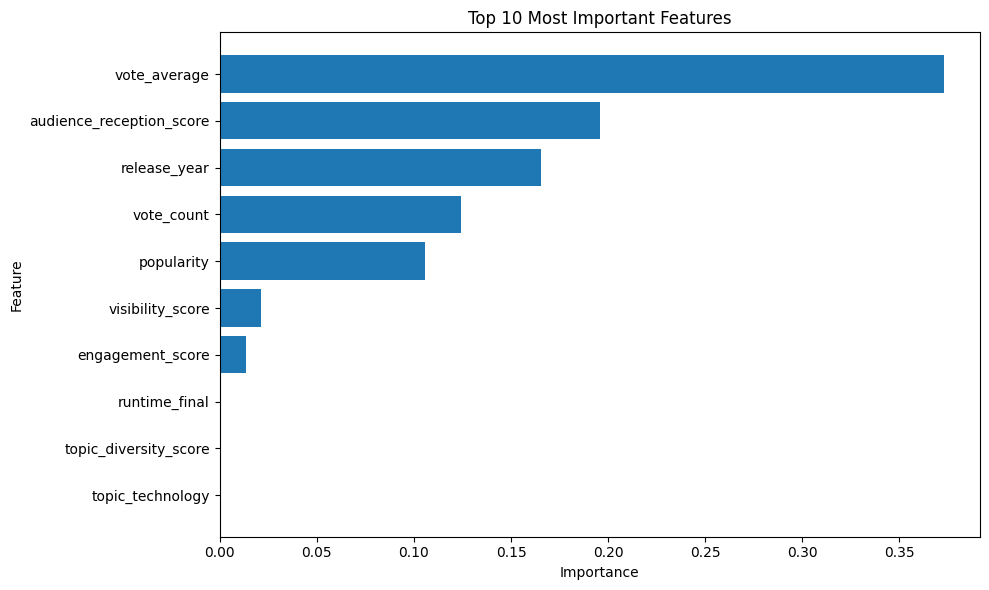

In [29]:
import matplotlib.pyplot as plt

top_features = importances.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features.index[::-1], top_features.values[::-1])
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Compare predictions vs Real

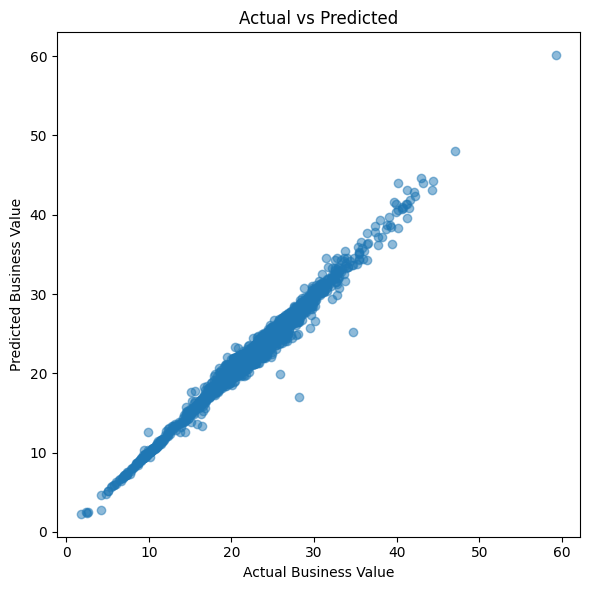

In [30]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Business Value")
plt.ylabel("Predicted Business Value")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

# Save predictions 

In [31]:
df["predicted_business_value"] = rf.predict(X)

df.to_csv("final_with_predictions.csv", index=False)

print("Saved: final_with_predictions.csv")

Saved: final_with_predictions.csv


residual analysis

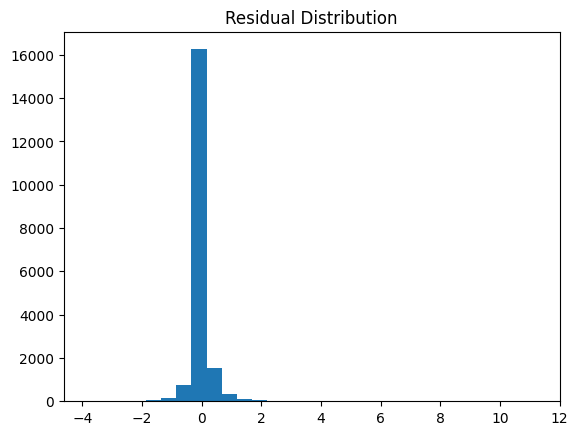

In [32]:
residuals = y_test - y_pred_rf

plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

predict new content 

In [33]:
new_data = X.iloc[:5]
predictions = rf.predict(new_data)

print (predictions)

[61.78683798 58.90446204 60.51446316 62.18253608 59.53508013]
